# News Article Classification

Dataset: News Category Dataset

https://www.kaggle.com/datasets/rmisra/news-category-dataset

In [ ]:
# Import libraries
import nltk
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import sklearn
from wordcloud import WordCloud
from nltk import word_tokenize
from nltk import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold
import re

In [ ]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

## Data Ingestion

In [ ]:
# Download dataset latest version
path = kagglehub.dataset_download("rmisra/news-category-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'news-category-dataset' dataset.
Path to dataset files: /kaggle/input/news-category-dataset


In [ ]:
# List files in the downloaded path to identify the data file
print("Files in the dataset directory:")
for file in os.listdir(path):
    print(file)

Files in the dataset directory:
News_Category_Dataset_v3.json


In [ ]:
# Construct the full path to the CSV file
file_path = os.path.join(path, 'News_Category_Dataset_v3.json')

# Load the file into a pandas DataFrame, ignoring malformed rows
df = pd.read_json(file_path, lines=True)

In [ ]:
# Inspect data
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  object        
 1   headline           209527 non-null  object        
 2   category           209527 non-null  object        
 3   short_description  209527 non-null  object        
 4   authors            209527 non-null  object        
 5   date               209527 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 9.6+ MB


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [ ]:
class_counts = df['category'].value_counts()
class_counts

,count
category,
POLITICS,35602
WELLNESS,17945
ENTERTAINMENT,17362
TRAVEL,9900
STYLE & BEAUTY,9814
PARENTING,8791
HEALTHY LIVING,6694
QUEER VOICES,6347
FOOD & DRINK,6340


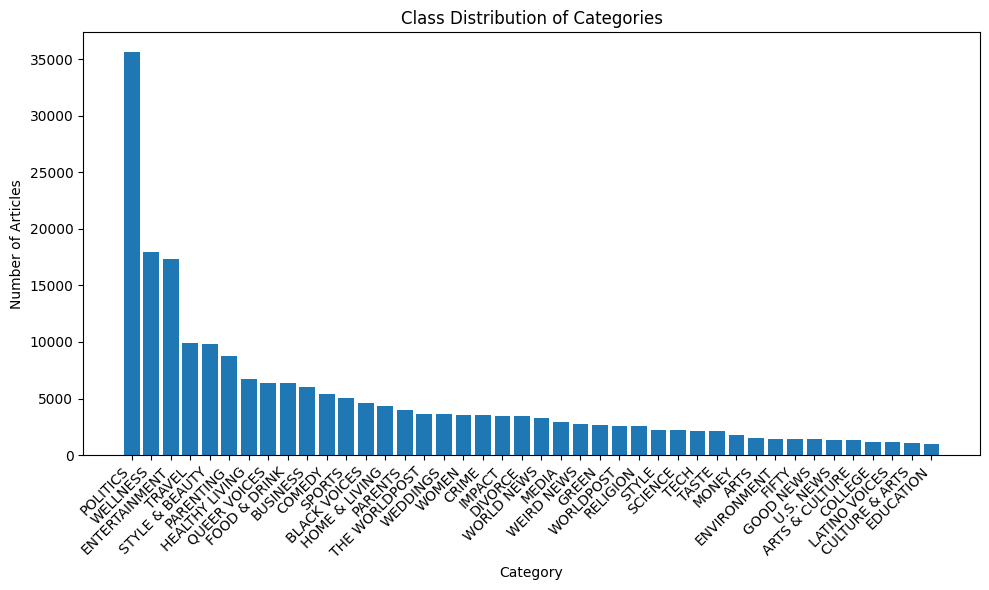

In [ ]:
# Visulaize data
classes = df['category'].value_counts().index
counts = df['category'].value_counts().values

plt.figure(figsize=(10, 6))
plt.bar(classes, counts)
plt.title("Class Distribution of Categories")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Data Preprocessing

In [ ]:
# Create subset with ten most represented classes (having at least 5500 samples)

sub_df = df.groupby('category').filter(lambda x: len(x) >= 5500).reset_index(drop=True)

sub_class_counts = sub_df['category'].value_counts()
sub_class_counts

,count
category,
POLITICS,35602
WELLNESS,17945
ENTERTAINMENT,17362
TRAVEL,9900
STYLE & BEAUTY,9814
PARENTING,8791
HEALTHY LIVING,6694
QUEER VOICES,6347
FOOD & DRINK,6340


In [ ]:
# Create subset with balanced classes based on lowest class count
samples_per_class = 5992

balanced_df = sub_df.groupby('category').apply(
    lambda x: x.sample(min(len(x), samples_per_class), random_state=42)
).reset_index(drop=True)

print("Samples per category after balancing:")
print(balanced_df['category'].value_counts())
print(f"\nTotal samples: {len(balanced_df)}")

Samples per category after balancing:
category
BUSINESS          5992
ENTERTAINMENT     5992
FOOD & DRINK      5992
HEALTHY LIVING    5992
PARENTING         5992
POLITICS          5992
QUEER VOICES      5992
STYLE & BEAUTY    5992
TRAVEL            5992
WELLNESS          5992
Name: count, dtype: int64

Total samples: 59920


/tmp/ipykernel_13902/1764342089.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = sub_df.groupby('category').apply(


In [ ]:
# Concatenate headline and short_description
balanced_df['text'] = balanced_df['headline'] + ' ' + balanced_df['short_description']

# Convert text to lowercase
balanced_df['text'] = balanced_df['text'].str.lower()

# Remove punctuation, numbers, special characters
balanced_df['text'] = balanced_df['text'].str.replace(r'[^a-zA-Z\s]', '', regex=True)

# Remove unnecessary spaces
balanced_df['text'] = balanced_df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Add word tokenized column
balanced_df['word_tokens'] = balanced_df['text'].apply(word_tokenize)

# Remove stopwords
nlp = spacy.load("en_core_web_sm")
stop_words = nlp.Defaults.stop_words
balanced_df['word_tokens_no_stopwords'] = balanced_df['word_tokens'].apply(lambda tokens: [word for word in tokens if word not in stop_words])

# View processed data
balanced_df.head()

,link,headline,category,short_description,authors,date,text,word_tokens,word_tokens_no_stopwords
0,https://www.huffingtonpost.com/entry/how-to-ma...,How to Manage Your Personal Brand,BUSINESS,Make no mistake: If you have a Facebook accoun...,"Kevin O'Leary, Contributor",2015-04-20,how to manage your personal brand make no mist...,"[how, to, manage, your, personal, brand, make,...","[manage, personal, brand, mistake, facebook, a..."
1,https://www.huffingtonpost.com/entry/uber-ad-n...,It Looks Like Uber's Winning Its War With New ...,BUSINESS,Grab the popcorn.,Alexander C. Kaufman,2015-07-22,it looks like ubers winning its war with new y...,"[it, looks, like, ubers, winning, its, war, wi...","[looks, like, ubers, winning, war, new, york, ..."
2,https://www.huffingtonpost.com/entry/the-progr...,The Progressive Promise of Today's Technology,BUSINESS,"A digital policy for the new century, tailored...","Andrei Cherny, ContributorCEO, Aspiration.com",2015-04-04,the progressive promise of todays technology a...,"[the, progressive, promise, of, todays, techno...","[progressive, promise, todays, technology, dig..."
3,https://www.huffingtonpost.com/entry/dont-let-...,Don't Let These 5 Confusing Words Mar Your Image,BUSINESS,"Tom's an articulate physician, totally able to...","Dianna Booher, ContributorCEO, BooherResearch....",2015-04-02,dont let these confusing words mar your image ...,"[dont, let, these, confusing, words, mar, your...","[dont, let, confusing, words, mar, image, toms..."
4,https://www.huffingtonpost.com/entry/what-you-...,What You Don't Know About Overnight Success,BUSINESS,"I've been fighting this thing for 32 years. ""O...","Grant Cardone, ContributorNew York Times bests...",2015-06-23,what you dont know about overnight success ive...,"[what, you, dont, know, about, overnight, succ...","[dont, know, overnight, success, ive, fighting..."


In [ ]:
# Display average number of tokens in X
avg_tokens_no_stopwords = balanced_df['word_tokens_no_stopwords'].apply(len).mean()

print(f"Average number of tokens in 'word_tokens_no_stopwords': {avg_tokens_no_stopwords:.2f}")

Average number of tokens in 'word_tokens_no_stopwords': 16.46


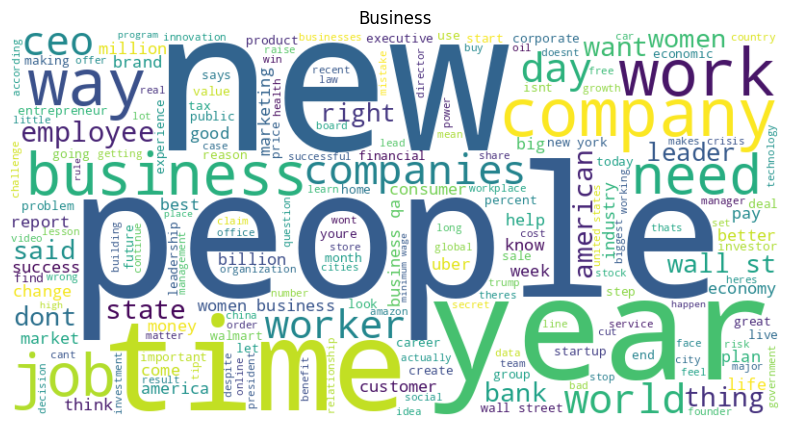

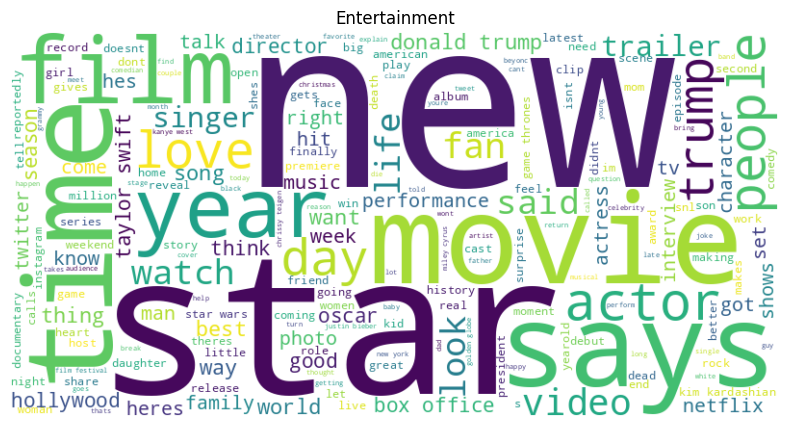

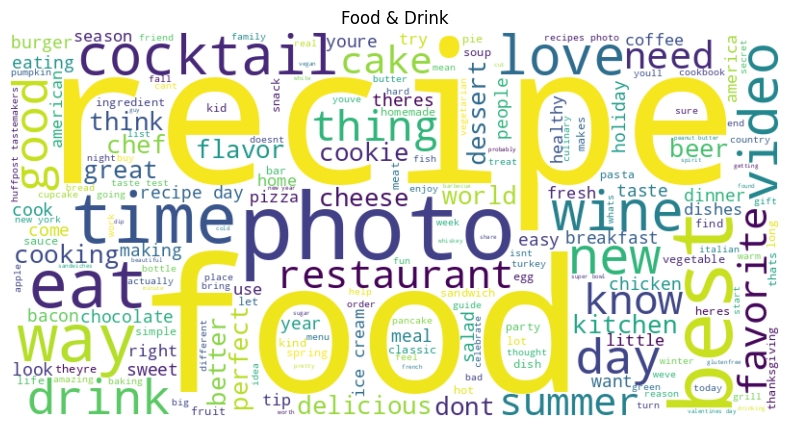

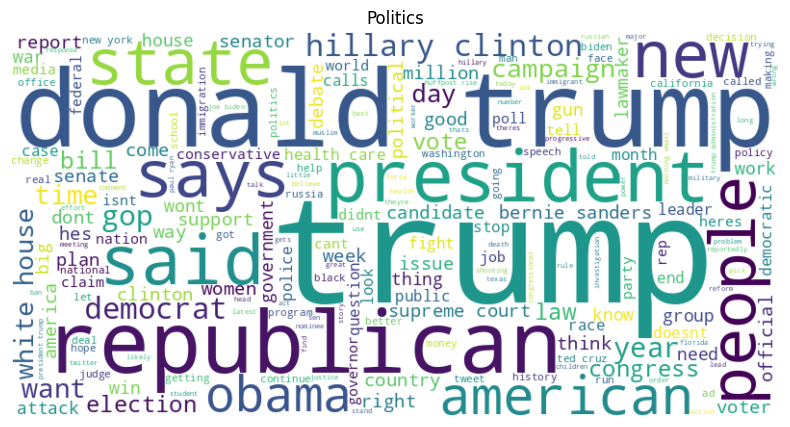

In [ ]:
# Display word clouds for a few categories

# Business
# Get all tokens for a Wellness category as a string
business_text = ' '.join([
    ' '.join(tokens)
    for tokens in balanced_df[balanced_df['category'] == 'BUSINESS']['word_tokens_no_stopwords']
])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(business_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Business')
plt.show()

# Entertainment
entertainment_text = ' '.join([
    ' '.join(tokens)
    for tokens in balanced_df[balanced_df['category'] == 'ENTERTAINMENT']['word_tokens_no_stopwords']
])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(entertainment_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Entertainment')
plt.show()

# Food & Drink
food_drink_text = ' '.join([
    ' '.join(tokens)
    for tokens in balanced_df[balanced_df['category'] == 'FOOD & DRINK']['word_tokens_no_stopwords']
])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(food_drink_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Food & Drink')
plt.show()

# Politics
politics_text = ' '.join([
    ' '.join(tokens)
    for tokens in balanced_df[balanced_df['category'] == 'POLITICS']['word_tokens_no_stopwords']
])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(politics_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Politics')
plt.show()

In [ ]:
# Encode class labels

le = LabelEncoder()
y = le.fit_transform(balanced_df['category'])

In [ ]:
# Split data into 70% train and 30% test
X = balanced_df['word_tokens_no_stopwords']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
)

In [ ]:
# Extract feautures
vectorizer = TfidfVectorizer(max_features=5000, analyzer=lambda x: x)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

## Model Training

In [ ]:
# Fit Logistic Regression model
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Fit SVM model
model_svm = LinearSVC(C=1.0, max_iter=1000)
model_svm.fit(X_train, y_train)

LinearSVC()

## Evaluation

In [ ]:
# Test models
y_pred_lr = model_lr.predict(X_test)
y_pred_svm = model_svm.predict(X_test)

In [ ]:
# Display accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Logistic Regression Accuracy:", accuracy_lr)
print("Support Vector Machine Accuracy:", accuracy_svm)

Logistic Regression Accuracy: 0.7310302625723186
Support Vector Machine Accuracy: 0.7179572763684913


In [ ]:
# Get original class names
class_names = le.classes_

# Dipslay classification report
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr, target_names=class_names))
print("Support Vector Machine Classification Report:\n", classification_report(y_test, y_pred_svm, target_names=class_names))

Logistic Regression Classification Report:
                 precision    recall  f1-score   support

      BUSINESS       0.70      0.72      0.71      1820
 ENTERTAINMENT       0.72      0.77      0.74      1831
  FOOD & DRINK       0.81      0.83      0.82      1765
HEALTHY LIVING       0.49      0.48      0.48      1757
     PARENTING       0.73      0.75      0.74      1777
      POLITICS       0.78      0.80      0.79      1829
  QUEER VOICES       0.90      0.76      0.82      1813
STYLE & BEAUTY       0.86      0.83      0.85      1773
        TRAVEL       0.79      0.80      0.79      1789
      WELLNESS       0.56      0.57      0.56      1822

      accuracy                           0.73     17976
     macro avg       0.73      0.73      0.73     17976
  weighted avg       0.73      0.73      0.73     17976

Support Vector Machine Classification Report:
                 precision    recall  f1-score   support

      BUSINESS       0.69      0.69      0.69      1820
 ENTERTAI

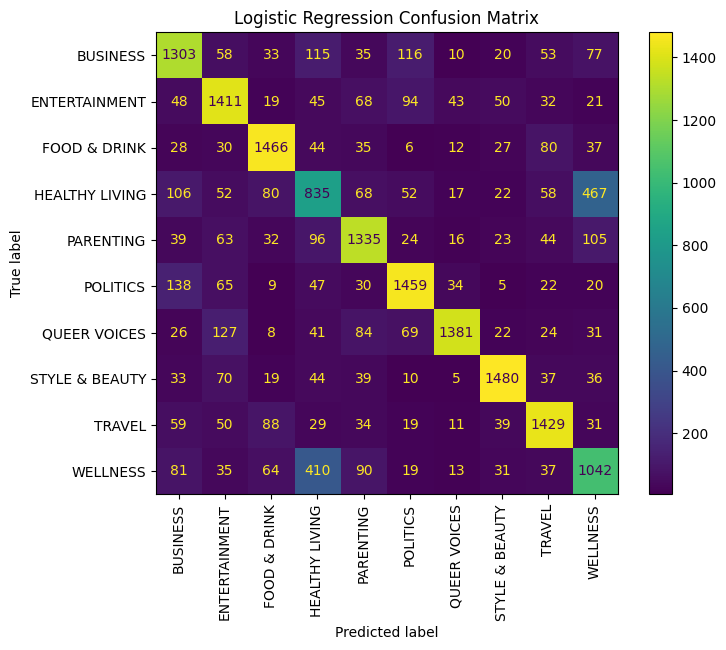

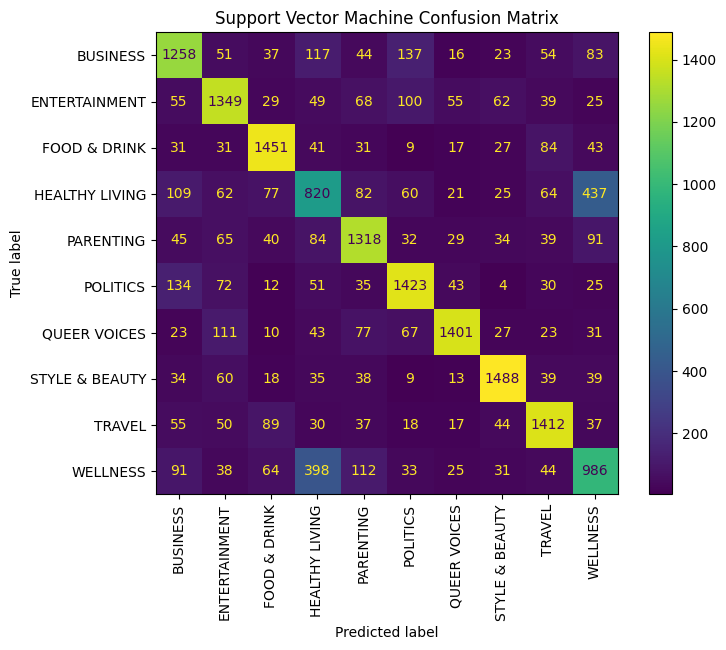

In [ ]:
# Display confusion matrix
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_display_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=class_names)
cm_display_lr.plot(ax=plt.gca(), xticks_rotation=90)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

plt.figure(figsize=(8, 6))
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_display_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=class_names)
cm_display_svm.plot(ax=plt.gca(), xticks_rotation=90)
plt.title("Support Vector Machine Confusion Matrix")
plt.show()

## Improvement

**Improvement 1: Use Naive Bayes**

In [ ]:
# Fit Naive Bayes model
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

MultinomialNB()

Naive Bayes Accuracy: 0.7091121495327103
Naive Bayes Classification Report:
                 precision    recall  f1-score   support

      BUSINESS       0.72      0.68      0.70      1820
 ENTERTAINMENT       0.73      0.71      0.72      1831
  FOOD & DRINK       0.77      0.85      0.81      1765
HEALTHY LIVING       0.47      0.43      0.45      1757
     PARENTING       0.66      0.74      0.70      1777
      POLITICS       0.76      0.81      0.78      1829
  QUEER VOICES       0.80      0.73      0.76      1813
STYLE & BEAUTY       0.83      0.82      0.82      1773
        TRAVEL       0.78      0.80      0.79      1789
      WELLNESS       0.54      0.53      0.54      1822

      accuracy                           0.71     17976
     macro avg       0.71      0.71      0.71     17976
  weighted avg       0.71      0.71      0.71     17976



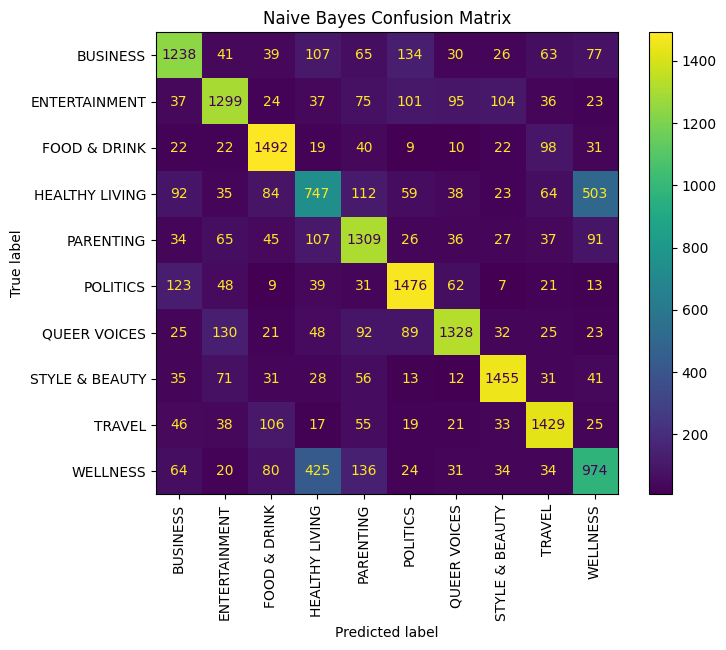

In [ ]:
# Evaluate Naive Bayes
y_pred_nb = model_nb.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb, target_names=class_names))

plt.figure(figsize=(8, 6))
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_display_rf = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=class_names)
cm_display_rf.plot(ax=plt.gca(), xticks_rotation=90)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Assessment: no improvement from Logistic Regression and SVM models.


**Improvement 2: Perform Cross-Validation**

In [ ]:
# Define number of folds
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Logistc Regression with Cross-Validation
# Create pipeline
model_lr = LogisticRegression(max_iter=1000, solver='saga')
pipeline_lr = Pipeline([('tfidf', TfidfVectorizer(max_features=5000, analyzer=lambda x: x)), ('lr', model_lr)])

scores_lr = cross_val_score(pipeline_lr, balanced_df['word_tokens_no_stopwords'], y, cv=kf, scoring='accuracy')

print(f"Logistic Regression Cross-Validation Accuracy: {scores_lr.mean():.4f} (+/- {scores_lr.std():.4f})")

Logistic Regression Cross-Validation Accuracy: 0.7243 (+/- 0.0067)


In [ ]:
# SVM with Cross-Validation
# Create pipeline
pipeline_svm = Pipeline([('tfidf', TfidfVectorizer(max_features=5000, analyzer=lambda x: x)), ('svm', model_svm)])

scores_svm = cross_val_score(pipeline_svm, balanced_df['word_tokens_no_stopwords'], y, cv=kf, scoring='accuracy')

print(f"SVM Cross-Validation Accuracy: {scores_svm.mean():.4f} (+/- {scores_svm.std():.4f})")

SVM Cross-Validation Accuracy: 0.7139 (+/- 0.0058)


In [ ]:
# Naive Bayes with Cross-Validation
# Create pipeline
pipeline_nb = Pipeline([('tfidf', TfidfVectorizer(max_features=5000, analyzer=lambda x: x)), ('nb', model_nb)])

scores_nb = cross_val_score(pipeline_nb, balanced_df['word_tokens_no_stopwords'], y, cv=kf, scoring='accuracy')

print(f"Naive Bayes Cross-Validation Accuracy: {scores_nb.mean():.4f} (+/- {scores_nb.std():.4f})")

Naive Bayes Cross-Validation Accuracy: 0.7056 (+/- 0.0046)


Assessment: little to no improvment

**Improvement 3: Increase max_features**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
)

# Increase max_feautures
vectorizer = TfidfVectorizer(max_features=30000, analyzer=lambda x: x)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
# Fit Logistic Regression model
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Fit SVM model
model_svm = LinearSVC(C=1.0, max_iter=1000)
model_svm.fit(X_train, y_train)

LinearSVC()

In [ ]:
# Test models
y_pred_lr = model_lr.predict(X_test)
y_pred_svm = model_svm.predict(X_test)

In [ ]:
# Display accuracy
mxft_accuracy_lr = accuracy_score(y_test, y_pred_lr)
mxft_accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Logistic Regression accuracy after increasing max_features:", mxft_accuracy_lr)
print("Support Vector Machine accuracy after increasing max_features:", mxft_accuracy_svm)

Logistic Regression accuracy after increasing max_features: 0.7491099243435692
Support Vector Machine accuracy after increasing max_features: 0.744826435246996


In [ ]:
# Dipslay classification report
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr, target_names=class_names))
print("Support Vector Machine Classification Report:\n", classification_report(y_test, y_pred_svm, target_names=class_names))

Logistic Regression Classification Report:
                 precision    recall  f1-score   support

      BUSINESS       0.73      0.75      0.74      1820
 ENTERTAINMENT       0.74      0.80      0.77      1831
  FOOD & DRINK       0.83      0.85      0.84      1765
HEALTHY LIVING       0.50      0.48      0.49      1757
     PARENTING       0.75      0.77      0.76      1777
      POLITICS       0.80      0.81      0.81      1829
  QUEER VOICES       0.91      0.77      0.83      1813
STYLE & BEAUTY       0.87      0.85      0.86      1773
        TRAVEL       0.81      0.82      0.81      1789
      WELLNESS       0.57      0.58      0.57      1822

      accuracy                           0.75     17976
     macro avg       0.75      0.75      0.75     17976
  weighted avg       0.75      0.75      0.75     17976

Support Vector Machine Classification Report:
                 precision    recall  f1-score   support

      BUSINESS       0.72      0.73      0.72      1820
 ENTERTAI

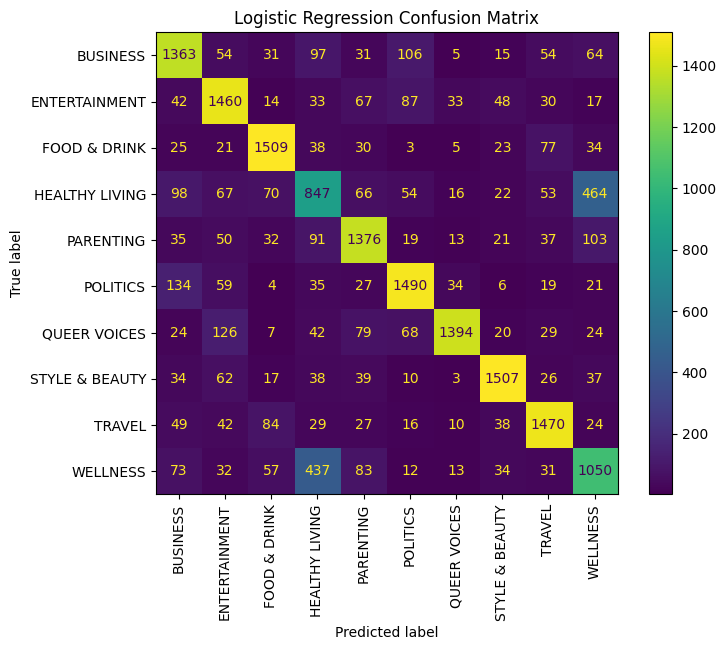

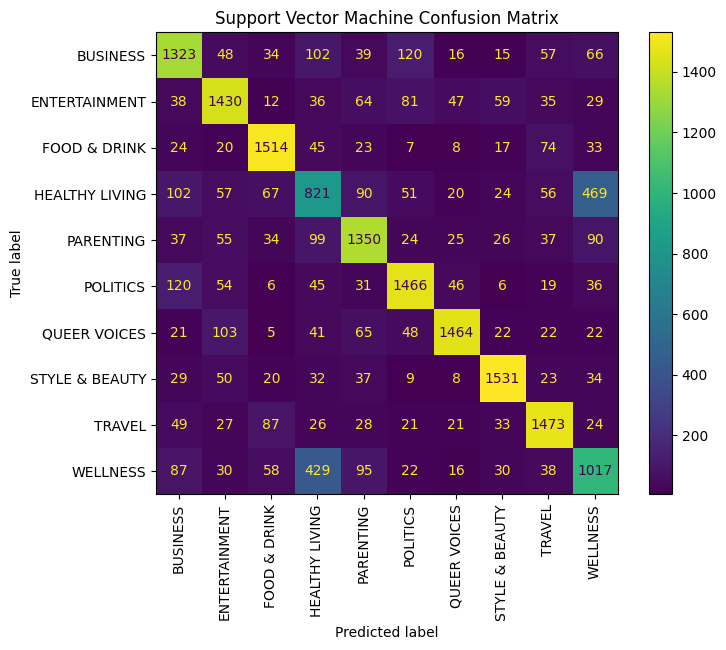

In [ ]:
# Display confusion matrix
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_display_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=class_names)
cm_display_lr.plot(ax=plt.gca(), xticks_rotation=90)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

plt.figure(figsize=(8, 6))
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_display_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=class_names)
cm_display_svm.plot(ax=plt.gca(), xticks_rotation=90)
plt.title("Support Vector Machine Confusion Matrix")
plt.show()

In [ ]:
# Dsiplay accuracy increase
print(f"Logistic Regression accuracy increase with increased max_features: {mxft_accuracy_lr - accuracy_lr:.4f}")
print(f"SVM accuracy increase with increased max_features: {mxft_accuracy_svm - accuracy_svm:.4f}")

Logistic Regression accuracy increase with increased max_features: 0.0181
SVM accuracy increase with increased max_features: 0.0269


Assessment:
* Increasing max_features produced a slight further improvement in accuracy of both models.
* Healthy Living and Wellness categories still perform quite poorly compared to the other eight categories.

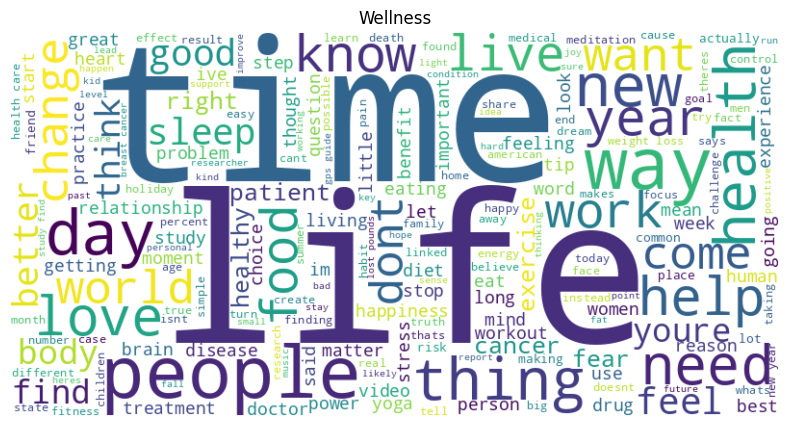

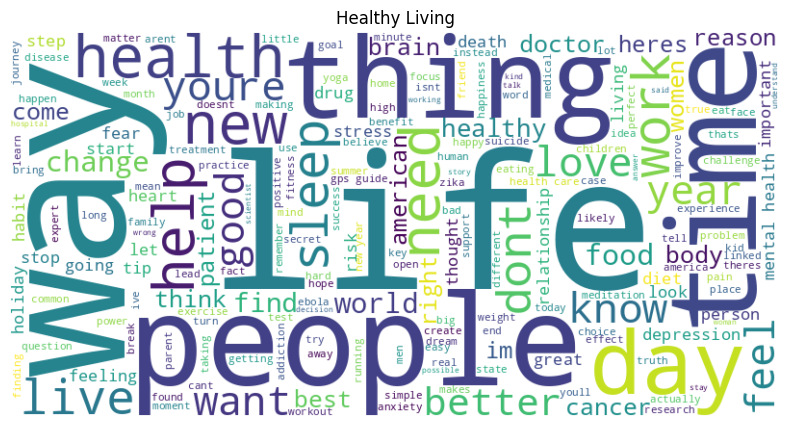

In [ ]:
# Display Wellness and Healthy Living word clouds

# Wellness
wellness_text = ' '.join([
    ' '.join(tokens)
    for tokens in balanced_df[balanced_df['category'] == 'WELLNESS']['word_tokens_no_stopwords']
])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(wellness_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Wellness')
plt.show()

# Healthy Living
healthy_living_text = ' '.join([
    ' '.join(tokens)
    for tokens in balanced_df[balanced_df['category'] == 'HEALTHY LIVING']['word_tokens_no_stopwords']
])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(healthy_living_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Healthy Living')
plt.show()

In [ ]:
# Display performance of all models
results = {
    'Metric': [
        'Logistic Regression Baseline',
        'SVM Baseline',
        'Naive Bayes Baseline',
        'Logistic Regression Cross Validation',
        'SVM Cross Validation',
        'Naive Bayes Cross Validation',
        'Logistic Regression Increased Max Features',
        'SVM Increased Max Features'
    ],
    'Value': [
        accuracy_lr,
        accuracy_svm,
        accuracy_nb,
        scores_lr.mean(),
        scores_svm.mean(),
        scores_nb.mean(),
        mxft_accuracy_lr,
        mxft_accuracy_svm
    ]
}

results_df = pd.DataFrame(results)
results_df['Value'] = results_df['Value'].map(lambda x: f'{x:.4f}')

print("Model Performance Summary:")
display(results_df)

Model Performance Summary:


,Metric,Value
0,Logistic Regression Baseline,0.7310
1,SVM Baseline,0.7180
2,Naive Bayes Baseline,0.7091
3,Logistic Regression Cross Validation,0.7243
4,SVM Cross Validation,0.7139
5,Naive Bayes Cross Validation,0.7056
6,Logistic Regression Increased Max Features,0.7491
7,SVM Increased Max Features,0.7448


## Results Interpretation

**Model performance Analysis**

* Baseline Logistic Regression and SVM models achieved ~73% and ~72% accuracy, respectiviely.
* Over the three improvement techniques applied, the first two -- introducing a Naive Bayes model and performing cross validation on Logistic Regression, SVM and Naive Bayes -- resulted in no improvement.
* Increasing max_features slightly improved performance of both the logistic regression and SVM models, reaching ~75 and ~74% respective accuracy.
* Logistic regression with max_features=30000 acheived the highest accuracy score of ~75%, with f1-scores of 86% for predicting Style & Beauty and 84% for Food & Drink.

**Strengths**
* Combined text fields (headline + short_description) to utilize best input features
* Successful preprocessing pipeline
* Balanced dataset
* No data leakage
* Experimentation with multiple models

**Limitations**
* Small amount of text per training sample (headline + short_description includes only ~16 tokens on average)
* Healthy Living and Wellness categories contain similar words making it hard to find patterns to differentiate them
* Word order is not considered by TF-IDF

**Potential improvements**
* Use data that includes entire articles or longer summaries
* Merge Healthy Living and Wellness categories
* Use bigrams and/or trigrams
* Use word embeddings, or try transformer-based models (e.g., BERT) which understand word context and semantics